# 조선주는 어디서 정보를 받는가 — 크로스에셋 확장
기존 케이스스터디(Part A~E) 결론: **조선 대형사는 강하게 같이 움직이지만(상관 0.62~0.74), 섹터 타이밍·페어·지주사 할인은 모두 검증 실패.**
같이 움직인다는 건 개별 뉴스보다 **공통 충격**이 크다는 뜻이므로, 그 충격이 어디서 오는지를 봅니다.

| 파트 | 질문 | 빈도 |
|---|---|---|
| **F** 미국 밤사이 → 한국 조선 | 미국 조선·LNG·해운 관련주가 밤사이 움직이면 다음 날 한국 조선주가 따라가는가. 시가에 다 반영되는가, 장중에 이어지는가 | 매일 (표본 큼) |
| **G** 지정학 충격 | 전쟁·홍해 사태·미중 조선 갈등 때 조선·해운·방산이 어떻게 반응했고, 조선 동조화가 올라갔는가 | 드묾 (사례 분석) |
| **H** 해운 → 조선 선후행 | 해운이 돈을 벌면 배를 발주한다 → 해운주가 조선주를 선행하는가 | 주간 |

**원칙**: 이벤트 목록(G)과 파라미터는 결과를 보기 전에 확정하고, 결과를 본 뒤 바꾸지 않는다.

In [1]:
%pip install -q finance-datareader pykrx yfinance statsmodels

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.dpi"] = 110

RES_DIR = "results_cross"; os.makedirs(RES_DIR, exist_ok=True)
START = "2015-01-01"
END   = pd.Timestamp.today().strftime("%Y-%m-%d")

# 한국 바스켓 (HJ중공업은 건설 비중, HD한국조선해양은 지주사 중복이라 조선 바스켓에서 제외)
SHIP     = {"329180": "HD HHI", "010620": "HD Mipo", "010140": "Samsung HI", "042660": "Hanwha Ocean"}
SHIP_ALL = {"009540": "HD KSOE", **SHIP}          # 동조화(상관) 계산은 기존과 동일하게 쓸 때 참고
SHIPPING = {"011200": "HMM", "028670": "Pan Ocean"}
DEFENSE  = {"012450": "Hanwha Aero", "079550": "LIG Nex1", "064350": "Hyundai Rotem"}

# 미국 (yfinance 티커). 상장 이전 구간은 자동으로 결측 처리됨
US_SIGNAL  = {"LNG": "Cheniere (US LNG exporter)", "HII": "Huntington Ingalls (US shipbuilder)",
              "ZIM": "ZIM (container shipping)"}
US_EXTRA   = {"BZ=F": "Brent crude"}
US_CONTROL = {"^GSPC": "S&P 500"}

COST_BUY  = 0.00015
COST_SELL = 0.00015 + 0.0015      # ※ 최신 거래세율 확인 후 수정

---
## Step 0. 데이터
Part F는 **시가**가 필요합니다(밤사이 갭 = 전일 종가→당일 시가, 장중 = 시가→종가).
시가와 종가가 **같은 수정 기준**이어야 갭 수익률이 왜곡되지 않습니다.

In [3]:
def load_ohlc(ticker, start, end):
    s, e = start.replace("-", ""), end.replace("-", "")
    try:
        from pykrx import stock
        df = stock.get_market_ohlcv(s, e, ticker)
        if df is not None and not df.empty:
            df = df.rename(columns={"시가": "Open", "종가": "Close", "거래량": "Volume"})
            return df[["Open", "Close", "Volume"]].astype(float)
    except Exception as ex:
        print(f"  pykrx 실패({ticker}): {ex}")
    try:
        import FinanceDataReader as fdr
        df = fdr.DataReader(ticker, start, end)
        if df is not None and not df.empty:
            print(f"  FDR 사용({ticker})")
            return df[["Open", "Close", "Volume"]].astype(float)
    except Exception as ex:
        print(f"  FDR 실패({ticker}): {ex}")
    return None

def load_kospi_ohlc(start, end):
    try:
        from pykrx import stock
        df = stock.get_index_ohlcv(start.replace("-", ""), end.replace("-", ""), "1001")
        if df is not None and not df.empty:
            return df.rename(columns={"시가": "Open", "종가": "Close"})[["Open", "Close"]].astype(float)
    except Exception as ex:
        print(f"  pykrx 지수 실패: {ex}")
    import FinanceDataReader as fdr
    return fdr.DataReader("KS11", start, end)[["Open", "Close"]].astype(float)

def load_panel(names, start, end):
    O, C, V = {}, {}, {}
    for t in names:
        df = load_ohlc(t, start, end)
        if df is None:
            print(f"  -> {t} 제외"); continue
        df.index = pd.to_datetime(df.index)
        O[t], C[t], V[t] = df["Open"], df["Close"], df["Volume"]
        time.sleep(0.3)
    return pd.DataFrame(O), pd.DataFrame(C), pd.DataFrame(V)

kospi = load_kospi_ohlc(START, END); kospi.index = pd.to_datetime(kospi.index)
CAL = kospi.index
panels = {}
for grp, names in [("ship", SHIP_ALL), ("shipping", SHIPPING), ("defense", DEFENSE)]:
    print(f"== {grp}")
    O, C, V = load_panel(names, START, END)
    panels[grp] = (O.reindex(CAL), C.reindex(CAL), V.reindex(CAL))

KRX 로그인 실패: KRX_ID 또는 KRX_PW 환경 변수가 설정되지 않았습니다.
Error occurred in get_index_ohlcv_by_date: Expecting value: line 1 column 1 (char 0)


Error occurred in __fetch: Expecting value: line 1 column 1 (char 0)
  pykrx 지수 실패: '지수명'


== ship


== shipping


== defense


In [4]:
def kr_returns(O, C, V, cap=0.305):
    halt = (V == 0) | V.isna() | (O <= 0)
    cc = C.pct_change(fill_method=None)
    gap = O / C.shift(1) - 1
    intra = C / O - 1
    bad = halt | (cc.abs() > cap) | (gap.abs() > cap) | (intra.abs() > cap)
    n_bad = int((bad & ~halt).values.sum())
    if n_bad:
        print(f"  비정상 수익률 {n_bad}개 NaN 처리 (수정주가 기준 불일치 가능 → 확인 필요)")
    return cc.mask(bad), gap.mask(bad), intra.mask(bad)

R = {}
for grp, (O, C, V) in panels.items():
    print(f"== {grp}")
    R[grp] = kr_returns(O, C, V)

k_cc    = kospi["Close"].pct_change(fill_method=None)
k_gap   = kospi["Open"] / kospi["Close"].shift(1) - 1
k_intra = kospi["Close"] / kospi["Open"] - 1

def basket(df, cols):
    cols = [c for c in cols if c in df.columns]
    return df[cols].mean(axis=1, skipna=True)

ship_cols = list(SHIP.keys())
B = pd.DataFrame({
    "ship_cc_ex":    basket(R["ship"][0], ship_cols) - k_cc,
    "ship_gap_ex":   basket(R["ship"][1], ship_cols) - k_gap,
    "ship_intra_ex": basket(R["ship"][2], ship_cols) - k_intra,
    "ship_intra":    basket(R["ship"][2], ship_cols),
    "shipping_cc_ex": basket(R["shipping"][0], SHIPPING) - k_cc,
    "defense_cc_ex":  basket(R["defense"][0], DEFENSE) - k_cc,
    "kospi_cc": k_cc,
})
print(B.describe().T[["count", "mean", "std"]])

== ship
== shipping
== defense
                    count    mean    std
ship_cc_ex     2,874.0000  0.0002 0.0230
ship_gap_ex    2,874.0000  0.0004 0.0100
ship_intra_ex  2,875.0000 -0.0002 0.0211
ship_intra     2,875.0000 -0.0006 0.0231
shipping_cc_ex 2,874.0000 -0.0002 0.0252
defense_cc_ex  2,874.0000  0.0009 0.0242
kospi_cc       2,874.0000  0.0005 0.0143


In [5]:
import yfinance as yf
us_tickers = list(US_SIGNAL) + list(US_EXTRA) + list(US_CONTROL)
raw_us = yf.download(us_tickers, start=START, end=END, auto_adjust=True, progress=False)["Close"]
if isinstance(raw_us, pd.Series):
    raw_us = raw_us.to_frame(us_tickers[0])
raw_us.index = pd.to_datetime(raw_us.index).tz_localize(None)
# yfinance가 일부 티커를 에러 없이 0건으로 돌려주는 경우가 있어 재시도하고, 그래도 없으면 중단
for t in [c for c in us_tickers if c not in raw_us.columns or raw_us[c].notna().sum() == 0]:
    for _ in range(3):
        time.sleep(2)
        s = yf.download(t, start=START, end=END, auto_adjust=True, progress=False)["Close"]
        if isinstance(s, pd.DataFrame): s = s.iloc[:, 0]
        if s.notna().sum() > 0:
            s.index = pd.to_datetime(s.index).tz_localize(None); raw_us[t] = s; break
    assert raw_us[t].notna().sum() > 0, f"{t} 데이터 수신 실패"
# 수익률은 종목별 자기 거래일 기준으로 계산: 합집합 인덱스의 빈 행(예: 추수감사절에 원유만 거래) 때문에
# 다음 거래일 수익률이 NaN이 되는 것을 방지
us_ret = np.log(raw_us).apply(lambda s: s.dropna().diff()).reindex(raw_us.index)
print("미국 데이터 관측치:\n", us_ret.notna().sum())

미국 데이터 관측치:
 Ticker
BZ=F     2949
HII      2947
LNG      2947
ZIM      1419
^GSPC    2947
dtype: int64


---
# Part F. 미국 밤사이 → 다음 날 한국 조선주
**시점 맞추기가 전부입니다.** 미국 날짜 d의 종가는 한국 시간 d+1일 새벽에 나오므로,
한국 거래일 k의 **시가 전에 새로 알려진** 미국 정보 = *직전 한국 거래일 이상, k 미만* 날짜의 미국 수익률 합.
(한국 휴장으로 미국 장이 여러 번 열렸으면 합산)

- **신호** = 미국 조선·LNG·해운 관련주 평균 수익률 − S&P500 수익률 (미국 시장 전체 움직임 제거)
- **가설 F1**: 신호가 다음 날 한국 조선 **갭**(전일 종가→시가, KOSPI 대비)을 설명한다 → 정보 전달 존재
- **가설 F2**: 신호가 **장중**(시가→종가) 수익률도 설명한다 → 시가에 덜 반영, 매매 가능
  (F1만 성립하고 F2가 없으면 "정보는 전달되지만 시가에 이미 다 반영" = 효율적)

In [6]:
def align_us_to_kr(us_ret, kr_dates):
    us_idx = us_ret.index
    out = np.full((len(kr_dates), us_ret.shape[1]), np.nan)
    prev = kr_dates[0] - pd.Timedelta(days=5)
    for i, k in enumerate(kr_dates):
        m = (us_idx >= prev) & (us_idx < k)
        if m.any():
            out[i] = us_ret.loc[m].sum(min_count=1).values
        prev = k
    return pd.DataFrame(out, index=kr_dates, columns=us_ret.columns)

usk = align_us_to_kr(us_ret, CAL)
sig_cols = [c for c in US_SIGNAL if c in usk.columns]
F = B.copy()
F["us_ship"] = usk[sig_cols].mean(axis=1, skipna=True)
F["spx"] = usk["^GSPC"]
F["brent"] = usk["BZ=F"] if "BZ=F" in usk else np.nan
F["signal"] = F["us_ship"] - F["spx"]

# 검증: 같은 날 미국 수익률(=미래 정보)을 쓰면 안 됨. 정렬이 맞는지 샘플 출력
print(F[["signal", "ship_gap_ex", "ship_intra_ex"]].dropna().head())

            signal  ship_gap_ex  ship_intra_ex
Date                                          
2015-01-06 -0.0043      -0.0159        -0.0092
2015-01-07  0.0133      -0.0054         0.0185
2015-01-08 -0.0177       0.0020        -0.0119
2015-01-09  0.0102       0.0090         0.0056
2015-01-12  0.0079      -0.0003        -0.0107


In [7]:
def hac_ols(y, X, lags=5):
    d = pd.concat([y, X], axis=1).dropna()
    res = sm.OLS(d.iloc[:, 0], sm.add_constant(d.iloc[:, 1:])).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return res

rows = []
for target in ["ship_gap_ex", "ship_intra_ex", "ship_cc_ex"]:
    res = hac_ols(F[target], F[["us_ship", "spx", "brent"]])
    for v in ["us_ship", "spx", "brent"]:
        rows.append({"target": target, "var": v, "coef": res.params[v], "HAC t": res.tvalues[v],
                     "R2": res.rsquared, "N": int(res.nobs)})
tblF1 = pd.DataFrame(rows).set_index(["target", "var"])
display(tblF1)
tblF1.to_csv(f"{RES_DIR}/F1_regression.csv", encoding="utf-8-sig")
print("해석: gap의 us_ship 계수 유의 → F1 지지 / intra의 계수 유의 → F2 지지")

coef   HAC t     R2     N
target        var                                 
ship_gap_ex   us_ship  0.0224  1.5384 0.0409  2780
              spx      0.0915  4.3065 0.0409  2780
              brent    0.0457  3.9586 0.0409  2780
ship_intra_ex us_ship  0.1029  3.6767 0.0149  2780
              spx     -0.2031 -4.6388 0.0149  2780
              brent    0.0560  3.3638 0.0149  2780
ship_cc_ex    us_ship  0.1252  4.2518 0.0259  2780
              spx     -0.1080 -2.2828 0.0259  2780
              brent    0.1015  5.4849 0.0259  2780

해석: gap의 us_ship 계수 유의 → F1 지지 / intra의 계수 유의 → F2 지지


,ship_gap_ex,ship_intra_ex,N
q,,,
Q1 (US down),-0.0181,-0.3309,557
Q2,-0.0028,-0.1382,556
Q3,0.0414,-0.0530,556
Q4,0.1063,0.1843,556
Q5 (US up),0.0851,0.2681,557


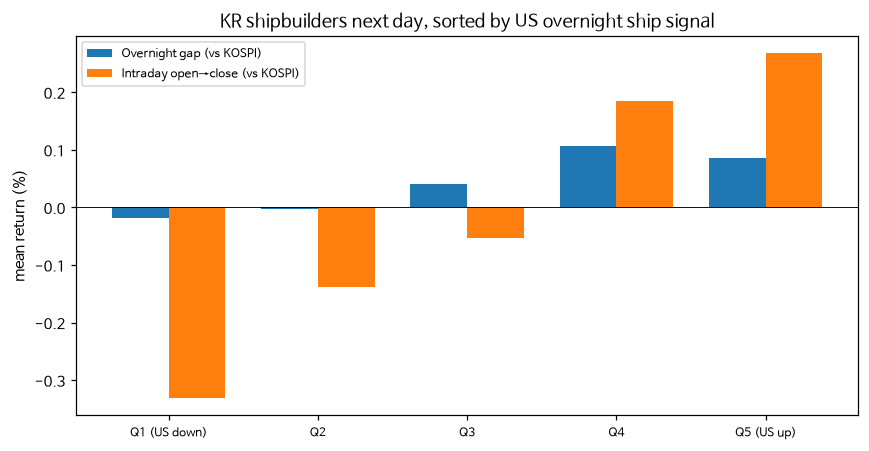

※ 분위 경계는 전체 표본 기준(기술통계용). 전략은 아래 셀에서 과거 정보만으로 판정


In [8]:
d = F[["signal", "ship_gap_ex", "ship_intra_ex"]].dropna().copy()
d["q"] = pd.qcut(d["signal"], 5, labels=["Q1 (US down)", "Q2", "Q3", "Q4", "Q5 (US up)"])
qt = d.groupby("q", observed=False)[["ship_gap_ex", "ship_intra_ex"]].mean() * 100
qt["N"] = d.groupby("q", observed=False).size()
display(qt)
qt.to_csv(f"{RES_DIR}/F2_quintiles.csv", encoding="utf-8-sig")

x = np.arange(5); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(x - w/2, qt["ship_gap_ex"], w, label="Overnight gap (vs KOSPI)")
ax.bar(x + w/2, qt["ship_intra_ex"], w, label="Intraday open→close (vs KOSPI)")
ax.set_xticks(x); ax.set_xticklabels(qt.index, fontsize=8); ax.axhline(0, color="k", lw=0.6)
ax.set_ylabel("mean return (%)"); ax.legend(fontsize=8)
ax.set_title("KR shipbuilders next day, sorted by US overnight ship signal")
plt.tight_layout(); plt.savefig(f"{RES_DIR}/fig_F1_quintiles.png", bbox_inches="tight"); plt.show()
print("※ 분위 경계는 전체 표본 기준(기술통계용). 전략은 아래 셀에서 과거 정보만으로 판정")

In [9]:
def metrics(r, name=""):
    r = r.dropna()
    if len(r) < 60: return {"strategy": name}
    yrs = len(r) / 252; cum = (1 + r).prod()
    cagr = cum ** (1 / yrs) - 1; vol = r.std() * np.sqrt(252)
    eq = (1 + r).cumprod(); mdd = (eq / eq.cummax() - 1).min()
    return {"strategy": name, "CAGR(%)": cagr * 100, "Vol(%)": vol * 100,
            "Sharpe": cagr / vol if vol > 0 else np.nan, "MDD(%)": mdd * 100, "Days": len(r)}

# 과거 분포 대비 백분위 (룩어헤드 방지). 상위 20%인 날만 시가 매수 → 종가 매도
rank = F["signal"].expanding(min_periods=250).rank(pct=True)
on = (rank >= 0.8).astype(float)
gross = on * F["ship_intra"].fillna(0)
cost = on * (COST_BUY + COST_SELL)
rows = [metrics(gross, "F: top-20% signal, open→close (gross)"),
        metrics(gross - cost, "F: top-20% signal, open→close (net)"),
        metrics(F["ship_intra"].fillna(0), "Every day open→close (gross)")]
tblF3 = pd.DataFrame(rows).set_index("strategy")
tblF3["trade days"] = [int(on.sum()), int(on.sum()), int(F["ship_intra"].notna().sum())]
display(tblF3)
tblF3.to_csv(f"{RES_DIR}/F3_strategy.csv", encoding="utf-8-sig")
avg_gain = F.loc[on > 0, "ship_intra"].mean()
print(f"신호일 평균 장중 수익 {avg_gain*100:.3f}% vs 왕복비용 {(COST_BUY+COST_SELL)*100:.3f}%")
print("※ 실제 시가 체결은 동시호가·슬리피지로 더 불리함")

,CAGR(%),Vol(%),Sharpe,MDD(%),Days,trade days
strategy,,,,,,
"F: top-20% signal, open→close (gross)",11.2499,18.6080,0.6046,-22.1862,2875,598
"F: top-20% signal, open→close (net)",1.2412,18.5491,0.0669,-30.7954,2875,598
Every day open→close (gross),-18.8069,36.6948,-0.5125,-92.4029,2875,2875


신호일 평균 장중 수익 0.236% vs 왕복비용 0.180%
※ 실제 시가 체결은 동시호가·슬리피지로 더 불리함


---
# Part G. 지정학 충격 이벤트 스터디
⚠️ **아래 목록은 후보입니다. 각 날짜를 출처로 검증하고, 결과를 보기 전에 목록을 확정하세요.**
결과를 본 뒤 이벤트를 넣거나 빼면 결론이 오염됩니다.

- `date_kst`: 한국 시장이 그 정보를 **처음 반영할 수 있는 날** (미국 발표는 보통 한국 다음 날). 휴장이면 다음 거래일로 자동 이동
- `exp_ship`: 결과를 보기 전 적어두는 **조선 반응 예상 부호** (+, −, ?)
- 교란(`confound`)이 있는 이벤트는 해석 시 따로 표시

In [10]:
# 날짜 검증 완료(2026-09-25): 11개 모두 출처로 발생 시각 확인, date_kst 변경·제외 없음
# (근거: results_cross/G0_event_verification.csv). 검증 중 발견한 교란 2건만 confound에 기록(exp_ship 불변)
EVENTS = pd.DataFrame([
    # date_kst,     event,                                         exp_ship, confound
    ("2022-02-24", "Russia invades Ukraine",                       "+", ""),
    ("2022-09-27", "Nord Stream pipeline sabotage",                "+", ""),
    ("2023-10-10", "Hamas attack on Israel (10/7, 1st KR day)",   "?", ""),
    ("2023-11-20", "Houthis seize Galaxy Leader (Red Sea)",        "?", ""),
    ("2023-12-18", "Major carriers pause Red Sea transits",       "?", ""),
    ("2024-01-12", "US/UK strikes on Houthis",                     "?", ""),
    ("2024-11-07", "US president-elect cites Korea shipbuilding cooperation", "+", "US election result 1 day earlier (KST 11/6)"),
    ("2025-02-24", "USTR proposes fees on China-built ships",      "+", ""),
    ("2025-04-10", "US maritime executive order",                  "+", "US tariff pause same day"),
    ("2025-04-18", "USTR final action on China shipbuilding",      "+", ""),
    ("2025-10-14", "China sanctions Hanwha Ocean US subsidiaries", "-", "US & China port fees took effect same day"),
], columns=["date_kst", "event", "exp_ship", "confound"])
EVENTS["date_kst"] = pd.to_datetime(EVENTS["date_kst"])
p = CAL.searchsorted(EVENTS["date_kst"])
EVENTS["t0"] = [CAL[i] if i < len(CAL) else pd.NaT for i in p]
EVENTS["pos"] = [CAL.get_loc(d) if pd.notna(d) else -1 for d in EVENTS["t0"]]
display(EVENTS)

,date_kst,event,exp_ship,confound,t0,pos
0,2022-02-24,Russia invades Ukraine,+,,2022-02-24,1758
1,2022-09-27,Nord Stream pipeline sabotage,+,,2022-09-27,1903
2,2023-10-10,"Hamas attack on Israel (10/7, 1st KR day)",?,,2023-10-10,2157
3,2023-11-20,Houthis seize Galaxy Leader (Red Sea),?,,2023-11-20,2186
4,2023-12-18,Major carriers pause Red Sea transits,?,,2023-12-18,2206
5,2024-01-12,US/UK strikes on Houthis,?,,2024-01-12,2222
6,2024-11-07,US president-elect cites Korea shipbuilding co...,+,US election result 1 day earlier (KST 11/6),2024-11-07,2421
7,2025-02-24,USTR proposes fees on China-built ships,+,,2025-02-24,2491
8,2025-04-10,US maritime executive order,+,US tariff pause same day,2025-04-10,2523
9,2025-04-18,USTR final action on China shipbuilding,+,,2025-04-18,2529


In [11]:
EST, WINS = (-250, -30), {"[0,+1]": (0, 1), "[0,+5]": (0, 5), "[0,+20]": (0, 20)}

def mm_car(r, m, pos):
    if pos < 0 or pos + EST[0] < 0 or pos + 20 >= len(r): return None
    y, x = r.iloc[pos + EST[0]:pos + EST[1] + 1].values, m.iloc[pos + EST[0]:pos + EST[1] + 1].values
    ok = ~np.isnan(y) & ~np.isnan(x)
    if ok.sum() < 120: return None
    b, a = np.polyfit(x[ok], y[ok], 1)
    ar = r.iloc[pos:pos + 21].values - (a + b * m.iloc[pos:pos + 21].values)
    return {k: np.nansum(ar[s:e + 1]) for k, (s, e) in WINS.items()}

baskets = {"ship": basket(R["ship"][0], ship_cols), "shipping": basket(R["shipping"][0], SHIPPING),
           "defense": basket(R["defense"][0], DEFENSE)}

def avg_corr(df):
    c = df.corr().values; iu = np.triu_indices(c.shape[0], 1)
    return np.nanmean(c[iu])

ship_ex = R["ship"][0][ship_cols].sub(k_cc, axis=0)
rows = []
for _, e in EVENTS.iterrows():
    row = {"event": e["event"], "t0": e["t0"].date() if pd.notna(e["t0"]) else None,
           "exp_ship": e["exp_ship"], "confound": e["confound"]}
    for bn, br in baskets.items():
        c = mm_car(br, k_cc, e["pos"])
        for k in WINS:
            row[f"{bn} {k}"] = c[k] * 100 if c else np.nan
    pos = e["pos"]
    if pos >= 60 and pos + 60 < len(CAL):
        row["ship corr before"] = avg_corr(ship_ex.iloc[pos - 60:pos])
        row["ship corr after"]  = avg_corr(ship_ex.iloc[pos:pos + 60])
    rows.append(row)
G = pd.DataFrame(rows).set_index("event")
display(G)
G.to_csv(f"{RES_DIR}/G1_events.csv", encoding="utf-8-sig")

,t0,exp_ship,confound,"ship [0,+1]","ship [0,+5]","ship [0,+20]","shipping [0,+1]","shipping [0,+5]","shipping [0,+20]","defense [0,+1]","defense [0,+5]","defense [0,+20]",ship corr before,ship corr after
event,,,,,,,,,,,,,,
Russia invades Ukraine,2022-02-24,+,,-1.1235,1.0261,-2.1576,-1.3910,11.1474,-3.0017,4.9581,14.2508,12.6957,0.5913,0.7122
Nord Stream pipeline sabotage,2022-09-27,+,,-6.4507,-6.7935,-19.6012,5.8245,-2.0551,-6.3575,-1.7114,-3.3000,-11.8058,0.6387,0.3440
"Hamas attack on Israel (10/7, 1st KR day)",2023-10-10,?,,2.2334,-1.0978,-1.7215,-5.3354,-9.2264,-0.0200,3.5086,-1.9323,6.3755,0.6808,0.4772
Houthis seize Galaxy Leader (Red Sea),2023-11-20,?,,4.3279,3.5966,1.1486,2.7672,0.7897,10.1498,-1.8315,-2.3950,12.8539,0.6390,0.4137
Major carriers pause Red Sea transits,2023-12-18,?,,-5.1864,-7.6366,-10.5823,6.6186,4.5496,13.1895,2.0807,-2.9519,2.6555,0.4716,0.6269
US/UK strikes on Houthis,2024-01-12,?,,2.2252,2.5089,-11.9090,4.2240,3.4057,5.9616,-0.1934,0.7992,-4.5975,0.4885,0.6116
US president-elect cites Korea shipbuilding cooperation,2024-11-07,+,US election result 1 day earlier (KST 11/6),13.6197,24.4272,16.5631,1.1003,6.1095,6.0219,0.8506,1.0278,-31.3149,0.6362,0.5699
USTR proposes fees on China-built ships,2025-02-24,+,,5.4811,9.3520,-7.9941,7.4778,9.2902,4.2888,-0.5078,0.1335,-7.5455,0.5685,0.5210
US maritime executive order,2025-04-10,+,US tariff pause same day,6.1430,6.5910,3.7495,2.8316,0.9583,2.2055,5.6441,10.7997,6.1229,0.5650,0.4486


조선 [0,+5] 예상 부호 적중률: 71% (7개 중)
이벤트 후 조선 동조화 변화: 평균 -0.058, t=-1.23, p=0.247, N=11
※ 이벤트 수가 적어 통계 검정보다는 사례 비교로 해석할 것


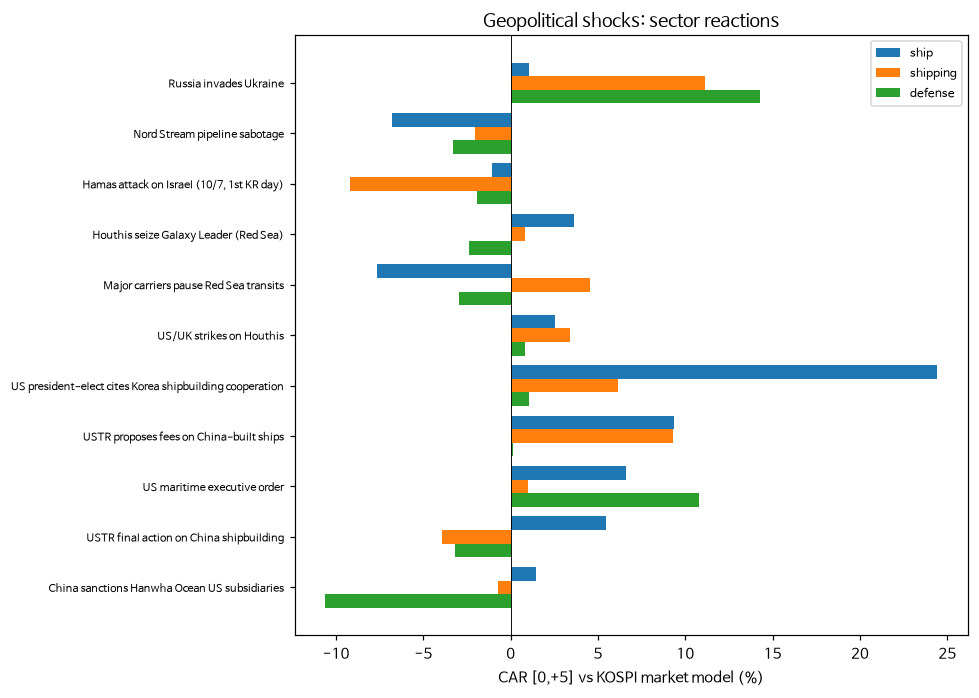

In [12]:
col = "ship [0,+5]"
g = G.dropna(subset=[col])
signed = g[g["exp_ship"].isin(["+", "-"])]
hit = (np.sign(signed[col]) == signed["exp_ship"].map({"+": 1, "-": -1})).mean()
print(f"조선 [0,+5] 예상 부호 적중률: {hit:.0%} ({len(signed)}개 중)")
dc = (g["ship corr after"] - g["ship corr before"]).dropna()
if len(dc) > 2:
    t, p = stats.ttest_1samp(dc, 0)
    print(f"이벤트 후 조선 동조화 변화: 평균 {dc.mean():+.3f}, t={t:.2f}, p={p:.3f}, N={len(dc)}")
print("※ 이벤트 수가 적어 통계 검정보다는 사례 비교로 해석할 것")

fig, ax = plt.subplots(figsize=(9, 0.45 * len(g) + 1.5))
y = np.arange(len(g)); h = 0.27
for i, bn in enumerate(["ship", "shipping", "defense"]):
    ax.barh(y + (i - 1) * h, g[f"{bn} [0,+5]"], h, label=bn)
ax.set_yticks(y); ax.set_yticklabels(g.index, fontsize=7); ax.invert_yaxis()
ax.axvline(0, color="k", lw=0.6); ax.set_xlabel("CAR [0,+5] vs KOSPI market model (%)")
ax.set_title("Geopolitical shocks: sector reactions"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{RES_DIR}/fig_G1_events.png", bbox_inches="tight"); plt.show()

---
# Part H. 해운 → 조선 선후행
일간 수익률은 노이즈가 커서 **주간(금요일 기준) KOSPI 대비 초과수익**으로 봅니다.
- 교차상관: corr(조선_t, 해운_{t−k}). k > 0에서 유의하면 해운이 선행
- 그랜저 인과: 양방향 모두 검정 (여러 시차를 보므로 **다중검정 주의**)
- 단순 전략: 최근 4주 해운 초과수익이 과거 대비 상위 30%면 다음 주 조선 보유

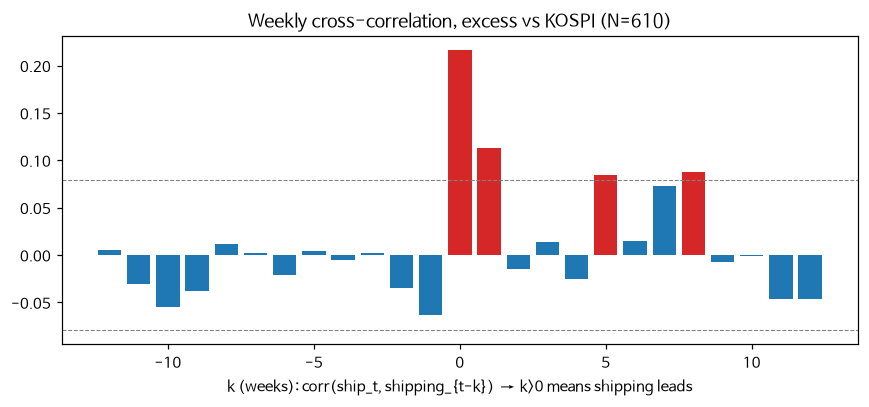

밴드를 넘은 시차: {0: 0.217, 1: 0.113, 5: 0.084, 8: 0.088}
95% 밴드 ±0.079. 25개 시차 중 1개 정도는 우연히 밴드를 넘음


In [13]:
def weekly(r):
    return (1 + r.fillna(0)).resample("W-FRI").prod() - 1

W = pd.DataFrame({"ship": weekly(B["ship_cc_ex"]), "shipping": weekly(B["shipping_cc_ex"])}).dropna()
W = W[(W != 0).all(axis=1)]
N = len(W); band = 1.96 / np.sqrt(N)
lags = range(-12, 13)
ccf = pd.Series({k: W["ship"].corr(W["shipping"].shift(k)) for k in lags})
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(list(ccf.index), ccf.values, color=["tab:red" if abs(v) > band else "tab:blue" for v in ccf.values])
ax.axhline(band, color="grey", ls="--", lw=0.7); ax.axhline(-band, color="grey", ls="--", lw=0.7)
ax.set_xlabel("k (weeks): corr(ship_t, shipping_{t-k})  →  k>0 means shipping leads")
ax.set_title(f"Weekly cross-correlation, excess vs KOSPI (N={N})")
plt.tight_layout(); plt.savefig(f"{RES_DIR}/fig_H1_ccf.png", bbox_inches="tight"); plt.show()
sig = ccf[ccf.abs() > band]
print("밴드를 넘은 시차:", {int(k): round(v, 3) for k, v in sig.items()} or "없음")
ccf.to_frame("ccf").to_csv(f"{RES_DIR}/H1_ccf.csv", encoding="utf-8-sig")
print(f"95% 밴드 ±{band:.3f}. 25개 시차 중 1개 정도는 우연히 밴드를 넘음")

In [14]:
import io, contextlib
rows = []
for cause, effect in [("shipping", "ship"), ("ship", "shipping")]:
    with contextlib.redirect_stdout(io.StringIO()):          # 구버전 statsmodels 출력 억제
        res = grangercausalitytests(W[[effect, cause]], maxlag=8)
    for L in [1, 2, 4, 8]:
        rows.append({"direction": f"{cause} → {effect}", "lag(weeks)": L,
                     "F p-value": res[L][0]["ssr_ftest"][1]})
tblH = pd.DataFrame(rows).pivot(index="direction", columns="lag(weeks)", values="F p-value")
display(tblH)
tblH.to_csv(f"{RES_DIR}/H2_granger.csv", encoding="utf-8-sig")
print("p < 0.05 → 원인 변수의 과거가 결과 변수 예측에 도움. 8개 검정이므로 보정 기준 ≈ 0.05/8 = 0.006")

lag(weeks),1,2,4,8
direction,,,,
ship → shipping,0.1460,0.2845,0.4700,0.8305
shipping → ship,0.0064,0.0298,0.0988,0.0105


p < 0.05 → 원인 변수의 과거가 결과 변수 예측에 도움. 8개 검정이므로 보정 기준 ≈ 0.05/8 = 0.006


In [15]:
mom = (1 + W["shipping"]).rolling(4).apply(np.prod, raw=True) - 1
rk = mom.expanding(min_periods=104).rank(pct=True)
hold = (rk >= 0.7).astype(float).shift(1).fillna(0)           # t주 신호 → t+1주 보유
ship_w_raw = weekly(basket(R["ship"][0], ship_cols)).reindex(W.index)
d = pd.DataFrame({"hold": hold, "ship_ex": W["ship"], "ship": ship_w_raw}).dropna()

on, off = d.loc[d["hold"] > 0, "ship_ex"], d.loc[d["hold"] == 0, "ship_ex"]
X = sm.add_constant(d["hold"])
res = sm.OLS(d["ship_ex"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})
print(f"신호 주 조선 초과수익 {on.mean()*100:.3f}% (N={len(on)}) vs 비신호 주 {off.mean()*100:.3f}% (N={len(off)})")
print(f"차이 {res.params['hold']*100:.3f}%p, HAC t = {res.tvalues['hold']:.2f}")

for lbl, sl in [("~2020", slice(None, "2020-12-31")), ("2021~", slice("2021-01-01", None))]:
    s = d.loc[sl]
    a, b = s.loc[s["hold"] > 0, "ship_ex"].mean(), s.loc[s["hold"] == 0, "ship_ex"].mean()
    print(f"  {lbl}: 신호 {a*100:.3f}% vs 비신호 {b*100:.3f}%")

turn = d["hold"].diff().abs().fillna(d["hold"])
net = d["hold"] * d["ship"] - turn * (COST_BUY + COST_SELL) / 2
def wmetrics(r, name):
    r = r.dropna(); yrs = len(r) / 52; cagr = (1 + r).prod() ** (1 / yrs) - 1
    vol = r.std() * np.sqrt(52); eq = (1 + r).cumprod()
    return {"strategy": name, "CAGR(%)": cagr * 100, "Sharpe": cagr / vol, "MDD(%)": (eq / eq.cummax() - 1).min() * 100}
tblH3 = pd.DataFrame([wmetrics(net, "H: shipping-momentum → hold ship (net)"),
                      wmetrics(d["ship"], "Buy & hold ship basket")]).set_index("strategy")
display(tblH3)
tblH3.to_csv(f"{RES_DIR}/H3_strategy.csv", encoding="utf-8-sig")

신호 주 조선 초과수익 0.130% (N=155) vs 비신호 주 0.110% (N=455)
차이 0.020%p, HAC t = 0.05
  ~2020: 신호 0.268% vs 비신호 -0.190%
  2021~: 신호 0.006% vs 비신호 0.439%


,CAGR(%),Sharpe,MDD(%)
strategy,,,
H: shipping-momentum → hold ship (net),1.3843,0.0703,-43.8945
Buy & hold ship basket,11.1889,0.2729,-68.1232


### (선택) 플라시보 — 경제적 연결이 없는 자산과도 '선행'이 보이는가
비트코인 주간 수익률로 같은 교차상관을 그립니다. 여기서도 밴드를 넘는 시차가 비슷하게 나온다면,
H의 결과도 우연과 구별하기 어렵다는 뜻입니다.

In [16]:
RUN_PLACEBO = True
if RUN_PLACEBO:
    btc = yf.download("BTC-USD", start=START, end=END, auto_adjust=True, progress=False)["Close"]
    if isinstance(btc, pd.DataFrame): btc = btc.iloc[:, 0]
    btc.index = pd.to_datetime(btc.index).tz_localize(None)
    btc_w = btc.resample("W-FRI").last().pct_change()
    P = pd.DataFrame({"ship": W["ship"], "btc": btc_w}).dropna()
    bandp = 1.96 / np.sqrt(len(P))
    ccp = pd.Series({k: P["ship"].corr(P["btc"].shift(k)) for k in lags})
    print(f"BTC 플라시보: 밴드(±{bandp:.3f}) 초과 시차 {int((ccp.abs() > bandp).sum())}개 / 25개")
    print(f"해운      : 밴드(±{band:.3f}) 초과 시차 {int((ccf.abs() > band).sum())}개 / 25개")

BTC 플라시보: 밴드(±0.079) 초과 시차 1개 / 25개
해운      : 밴드(±0.079) 초과 시차 4개 / 25개
